In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import torchvision

In [24]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

# Import the data

In [25]:
trainOrgData = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=None)
testOrgData = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=None)


In [26]:
trainOrgData.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [27]:
# Extract trouser, pullover, sneaker only

idxTrain = (trainOrgData.targets == 1) | (trainOrgData.targets == 2) | (trainOrgData.targets == 7)
idxTest = (testOrgData.targets == 1) | (testOrgData.targets == 2) | (testOrgData.targets == 7)

trainData = trainOrgData.data[idxTrain]
testData = testOrgData.data[idxTest]

trainData = trainData / torch.max(testData)
trainData = 2*trainData - 1
trainData = trainData

testData = testData / torch.max(testData)
testData = 2*testData - 1
testData = testData

In [28]:
#trainData[0], testData[0], type(trainData[0]), trainData[0].dtype, trainData[0].max(), trainData[0].min(), trainData.size()

# Create the Data Loader

In [29]:
batch_size = 100

train_loader = torch.utils.data.DataLoader(trainData, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(testData, batch_size=batch_size, shuffle=True)

# Create classes for the discriminator and generator

In [30]:
class discriminatorNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 1)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = self.out(x)
        return torch.sigmoid(x)

dnet = discriminatorNet()
dnet.to(device)

y = dnet(torch.randn(5, 28*28).to(device))
y

tensor([[0.4865],
        [0.5585],
        [0.4879],
        [0.5234],
        [0.5110]], device='mps:0', grad_fn=<SigmoidBackward0>)

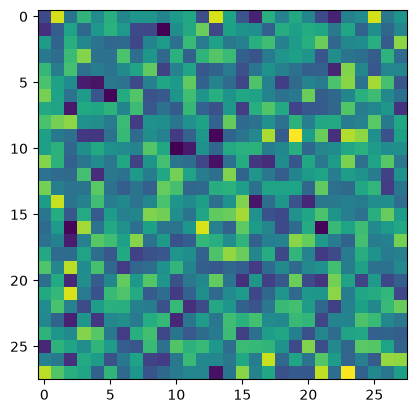

In [31]:
class generatorNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(64, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 28*28)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = self.out(x)
        return torch.tanh(x)

gnet = generatorNet()
gnet.to(device)
y = gnet(torch.randn(5, 64).to(device))
plt.imshow(y[0].detach().cpu().view(28,28))

# Train the model

In [32]:
loss_fn = nn.BCELoss()
d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.001)
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.001)


# Training Loop

# Instructor's Code. In one epoch only trains with 100 examples. Needs (a lot) more epochs to train. Better approach according to copilot

In [33]:

iterations = 50000

losses  = np.zeros((iterations, 2))
disDecs = np.zeros((iterations, 2))

for i in range(iterations):

    # ---- sample a random batch (like instructor) ----
    idx = torch.randint(trainData.shape[0], (batch_size,))
    real_images = trainData[idx].to(device).reshape(-1, 28*28)

    # ---- generate fake images ----
    z = torch.randn(batch_size, 64).to(device)
    fake_images = gnet(z)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # ---------------- Train discriminator ---------------- #
    pred_real = dnet(real_images)
    pred_fake = dnet(fake_images.detach())

    d_loss_real = loss_fn(pred_real, real_labels)
    d_loss_fake = loss_fn(pred_fake, fake_labels)
    d_loss = d_loss_real + d_loss_fake

    losses[i, 0]  = d_loss.item()
    disDecs[i, 0] = torch.mean((pred_real > 0.5).float()).detach()

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # ---------------- Train generator ---------------- #
    z = torch.randn(batch_size, 64).to(device)
    fake_images = gnet(z)
    pred_fake = dnet(fake_images)

    g_loss = loss_fn(pred_fake, real_labels)

    losses[i, 1]  = g_loss.item()
    disDecs[i, 1] = torch.mean((pred_fake > 0.5).float()).detach()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # status
    if (i+1) % 500 == 0:
        print(f"Iteration {i+1}/{iterations}")


Iteration 500/50000
Iteration 1000/50000
Iteration 1500/50000
Iteration 2000/50000
Iteration 2500/50000
Iteration 3000/50000
Iteration 3500/50000
Iteration 4000/50000
Iteration 4500/50000
Iteration 5000/50000
Iteration 5500/50000
Iteration 6000/50000
Iteration 6500/50000
Iteration 7000/50000
Iteration 7500/50000
Iteration 8000/50000
Iteration 8500/50000
Iteration 9000/50000
Iteration 9500/50000
Iteration 10000/50000
Iteration 10500/50000
Iteration 11000/50000
Iteration 11500/50000
Iteration 12000/50000
Iteration 12500/50000
Iteration 13000/50000
Iteration 13500/50000
Iteration 14000/50000
Iteration 14500/50000
Iteration 15000/50000
Iteration 15500/50000
Iteration 16000/50000
Iteration 16500/50000
Iteration 17000/50000
Iteration 17500/50000
Iteration 18000/50000
Iteration 18500/50000
Iteration 19000/50000
Iteration 19500/50000
Iteration 20000/50000
Iteration 20500/50000
Iteration 21000/50000
Iteration 21500/50000
Iteration 22000/50000
Iteration 22500/50000
Iteration 23000/50000
Iteratio

# My Code using dataloaders. In one epochs trains with full dataset

In [34]:
# epochs = 1000
#
# losses = np.zeros((epochs,2))
# disDecs = np.zeros((epochs,2))
#
# for epoch in range(epochs):
#     for x in train_loader:
#         real_images = x.to(device).reshape(-1,28*28)
#         fake_images = gnet(torch.randn(batch_size,64).to(device))
#
#         real_labels = torch.ones(batch_size,1).to(device)
#         fake_labels = torch.zeros(batch_size,1).to(device)
#
# #----------------- Train the discriminator ------------------#
#         pred_real = dnet(real_images)
#         d_loss_real = loss_fn(pred_real, real_labels)
#
#         pred_fake = dnet(fake_images)
#         d_loss_fake = loss_fn(pred_fake, fake_labels)
#
#         d_loss = d_loss_real + d_loss_fake
#
#         losses[epoch,0] = d_loss.item()
#         disDecs[epoch,0] = torch.mean((pred_real>0.5).float()).detach()
#
#         d_optimizer.zero_grad()
#         d_loss.backward()
#         d_optimizer.step()
#
# #----------------- Train the Generator ------------------#
#         fake_images = gnet(torch.randn(batch_size,64).to(device))
#         pred_fake = dnet(fake_images)
#
#         g_loss = loss_fn(pred_fake, real_labels)
#         losses[epoch,1] = g_loss.item()
#         disDecs[epoch,1] = torch.mean((pred_real>0.5).float()).detach()
#
#         g_optimizer.zero_grad()
#         g_loss.backward()
#         g_optimizer.step()
#
#     #if (epoch+1)%500==0:
#     msg = f'Epoch {epoch+1}/{epochs}'
#     print(msg)

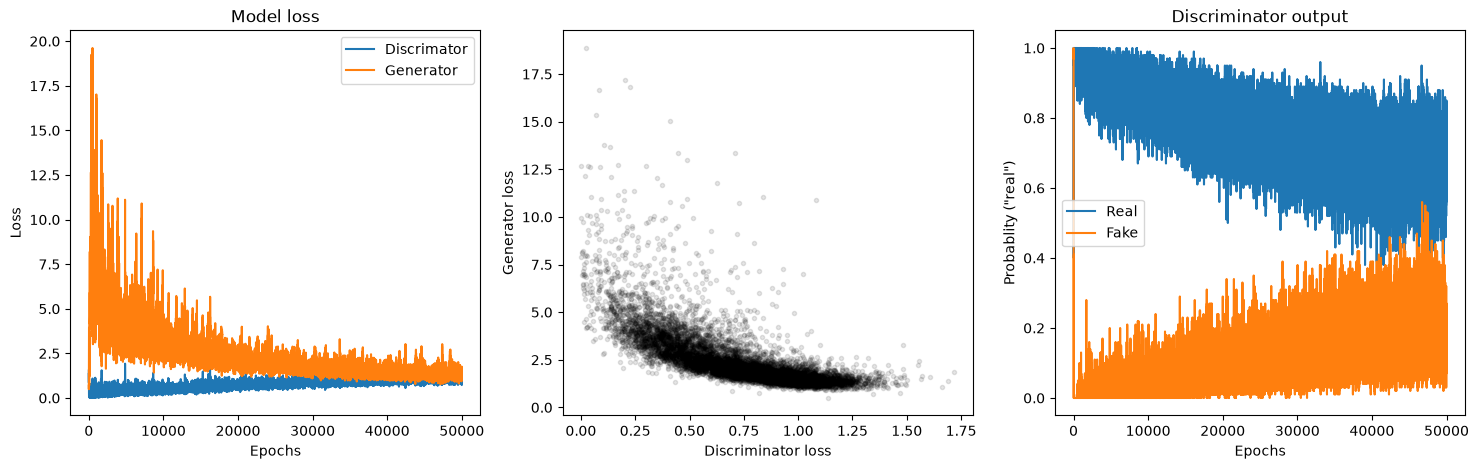

In [35]:
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(disDecs)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

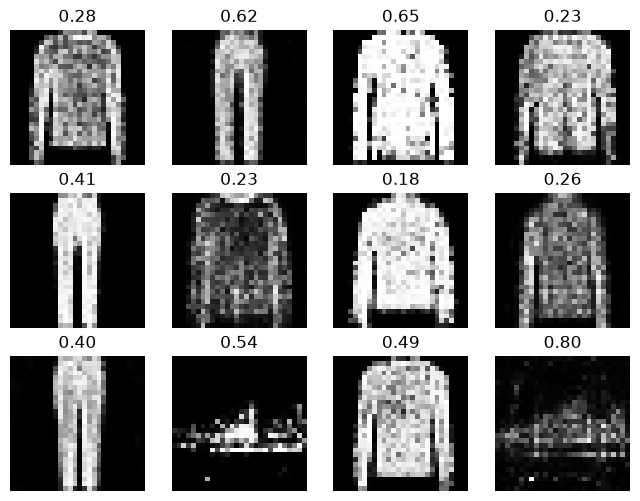

In [36]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()
discriminator = dnet(fake_data.to(device))

# and visualize...
fig,axs = plt.subplots(3,4,figsize=(8,6))
for i,ax in enumerate(axs.flatten()):
  ax.set_title(f'{discriminator[i].item():.2f}')
  ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
  ax.axis('off')

plt.show()